# EDA - Brottsstatistik

## Initial EDA

In [479]:
import pandas as pd
import duckdb
import matplotlib

df_raw = pd.read_excel('../data_files/brå_2021_2025_raw.xls', header=None)

df_raw.head(10)

,0,1,2,3,4,5,6,7,8,9,10
0,Anmälda brott,NaN,Brottsförebyggande rådet,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,2021,2021,2022,2022,2023,2023,2024,2024,2025,2025
3,NaN,Helår,Helår,Helår,Helår,Helår,Helår,Helår,Helår,Helår,Helår
4,NaN,Antal,/100 000 inv,Antal,/100 000 inv,Antal,/100 000 inv,Antal,/100 000 inv,Antal,/100 000 inv
5,Stadsdelsområde Bromma (Sthlm),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,3-7 kap. Brott mot person,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,3 kap. Brott mot liv och hälsa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,därav misshandel inkl. grov,472,581,458,558,506,615,511,617,501,603
9,3-7 kap. Brott mot person,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [480]:
df_raw.shape

(139, 11)

In [481]:
df_raw.columns

Index([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10], dtype='int64')

In [482]:
df_raw.iloc[2:5, :11]

,0,1,2,3,4,5,6,7,8,9,10
2,NaN,2021,2021,2022,2022,2023,2023,2024,2024,2025,2025
3,NaN,Helår,Helår,Helår,Helår,Helår,Helår,Helår,Helår,Helår,Helår
4,NaN,Antal,/100 000 inv,Antal,/100 000 inv,Antal,/100 000 inv,Antal,/100 000 inv,Antal,/100 000 inv


In [483]:
# Se alla brottstyper som innehåller data (not null)
# Kolumn 0 = Brottstyper

list(df_raw[0].dropna().unique())

['Anmälda brott',
 'Stadsdelsområde Bromma (Sthlm)',
 '3-7 kap. Brott mot person',
 '3 kap. Brott mot liv och hälsa',
 'därav misshandel inkl. grov',
 '4 kap. Brott mot frihet och frid',
 '5 kap. Ärekränkningsbrott',
 '6 kap. Sexualbrott',
 '7 kap. Brott mot familj',
 '8-12 kap. Brott mot förmögenhet',
 '8 kap. Stöld, rån m.m.',
 'därav biltillgrepp',
 'därav cykeltillgrepp',
 'därav stöld ur och från motordrivet fordon',
 'därav inbrottsstöld i bostad',
 'därav stöld och snatteri i butik, varuhus o.d.',
 'därav fickstöld',
 'därav rån, inkl. grovt',
 '9 kap. Bedrägeri och annan oredlighet',
 '10 kap. Förskingring och annan trolöshet',
 '11 kap. Brott mot borgenärer m.m.',
 '12 kap. Skadegörelsebrott',
 '13-15 kap. Brott mot allmänheten',
 '13 kap. Allmänfarliga brott',
 '14 kap. Förfalskningsbrott',
 '15 kap. Mened, falskt åtal m.m.',
 '16-20 kap. Brott mot staten',
 '16 kap. Brott mot allmän ordning',
 '17 kap. Brott mot allmän verksamhet',
 '18-20 kap. Högmålsbrott, brott mot rikets

### Kommentar:
Lite konstig struktur på filen..

* Rad 0-4: Headers/metadata
* Totalt antal brott: kolumn 1, 3, 5..
* Brott per capita: kolumn 2, 4, 6..

## Cleaning ##

Förbered tabellen för att enklare kunna filtrera och sedan rensa datan


### Behåll endast brottsdata per capita

In [484]:
# Skapa ny df med de rader vi vill behålla
# Kolumn 0 = brottstyp
# Kolumn 2,4,6.. = brott per capita

per_capita_cols = [0] + list(range(2,11,2))

df_cleaned = df_raw.iloc[:, per_capita_cols].copy()

df_cleaned.head(10)

,0,2,4,6,8,10
0,Anmälda brott,Brottsförebyggande rådet,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,2021,2022,2023,2024,2025
3,NaN,Helår,Helår,Helår,Helår,Helår
4,NaN,/100 000 inv,/100 000 inv,/100 000 inv,/100 000 inv,/100 000 inv
5,Stadsdelsområde Bromma (Sthlm),NaN,NaN,NaN,NaN,NaN
6,3-7 kap. Brott mot person,NaN,NaN,NaN,NaN,NaN
7,3 kap. Brott mot liv och hälsa,NaN,NaN,NaN,NaN,NaN
8,därav misshandel inkl. grov,581,558,615,617,603
9,3-7 kap. Brott mot person,NaN,NaN,NaN,NaN,NaN


### Lägg till kolumner/justera kolumnnamn

#### Döp om kolumner 0-10 (år och brottstyp)

In [485]:
# Döp om  kolumn '0' till 'Brottstyp'

df_cleaned = df_cleaned.rename(columns={0: 'Brottstyp'})

df_cleaned.head(5)

,Brottstyp,2,4,6,8,10
0,Anmälda brott,Brottsförebyggande rådet,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,2021,2022,2023,2024,2025
3,NaN,Helår,Helår,Helår,Helår,Helår
4,NaN,/100 000 inv,/100 000 inv,/100 000 inv,/100 000 inv,/100 000 inv


In [486]:
# Lägg till årtal i kolumn 2-10

years = [df_cleaned.iloc[2, i] for i in range(1, len(df_cleaned.columns))]

df_cleaned.columns = ['Brottstyp'] + years

df_cleaned.head(5)

,Brottstyp,2021,2022,2023,2024,2025
0,Anmälda brott,Brottsförebyggande rådet,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,2021,2022,2023,2024,2025
3,NaN,Helår,Helår,Helår,Helår,Helår
4,NaN,/100 000 inv,/100 000 inv,/100 000 inv,/100 000 inv,/100 000 inv


In [488]:
# Justera data type för brottsdatan per capita (str -> int) 

year_cols = ['2021', '2022', '2023', '2024', '2025']
df_cleaned[year_cols] = df_cleaned[year_cols].apply(pd.to_numeric, errors='coerce')

In [489]:
print(df_cleaned.dtypes)

Brottstyp        str
2021         float64
2022         float64
2023         float64
2024         float64
2025         float64
dtype: object


#### Lägg till radnummer

In [490]:
# För att vi ska kunna filtrera på område

df_cleaned['radnr'] = range(len(df_cleaned))

df_cleaned.head(10)


,Brottstyp,2021,2022,2023,2024,2025,radnr
0,Anmälda brott,NaN,NaN,NaN,NaN,NaN,0
1,NaN,NaN,NaN,NaN,NaN,NaN,1
2,NaN,2021.0,2022.0,2023.0,2024.0,2025.0,2
3,NaN,NaN,NaN,NaN,NaN,NaN,3
4,NaN,NaN,NaN,NaN,NaN,NaN,4
5,Stadsdelsområde Bromma (Sthlm),NaN,NaN,NaN,NaN,NaN,5
6,3-7 kap. Brott mot person,NaN,NaN,NaN,NaN,NaN,6
7,3 kap. Brott mot liv och hälsa,NaN,NaN,NaN,NaN,NaN,7
8,därav misshandel inkl. grov,581.0,558.0,615.0,617.0,603.0,8
9,3-7 kap. Brott mot person,NaN,NaN,NaN,NaN,NaN,9


#### Lägg till kolumn för område

In [491]:
# Hitta vilka rader som gälller för Bromma resp. Älvsjö

df_cleaned[df_cleaned['Brottstyp'].str.contains('Bromma|Älvsjö')]

,Brottstyp,2021,2022,2023,2024,2025,radnr
5,Stadsdelsområde Bromma (Sthlm),NaN,NaN,NaN,NaN,NaN,5
67,Stadsdelsområde Hägersten-Älvsjö (Sthlm),NaN,NaN,NaN,NaN,NaN,67
135,Stadsdelsområde Bromma (Sthlm),NaN,NaN,NaN,NaN,NaN,135
136,I juni 2016 har redovisningen av folkmängd änd...,NaN,NaN,NaN,NaN,NaN,136
137,Stadsdelsområde Hägersten-Älvsjö (Sthlm),NaN,NaN,NaN,NaN,NaN,137


In [492]:
# Lägg till kolumn med områdesnamn

BROMMA_START = 5
ÄLVSJÖ_START = 67

df_cleaned = duckdb.sql(f"""--sql
SELECT 
    *,
    CASE 
        WHEN radnr >= {BROMMA_START} AND radnr < {ÄLVSJÖ_START} THEN 'Bromma'
        WHEN radnr >= {ÄLVSJÖ_START} THEN 'Älvsjö'
    END AS område
FROM df_cleaned
""").df()

df_cleaned.head(10)

,Brottstyp,2021,2022,2023,2024,2025,radnr,område
0,Anmälda brott,NaN,NaN,NaN,NaN,NaN,0,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN
2,NaN,2021.0,2022.0,2023.0,2024.0,2025.0,2,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN
5,Stadsdelsområde Bromma (Sthlm),NaN,NaN,NaN,NaN,NaN,5,Bromma
6,3-7 kap. Brott mot person,NaN,NaN,NaN,NaN,NaN,6,Bromma
7,3 kap. Brott mot liv och hälsa,NaN,NaN,NaN,NaN,NaN,7,Bromma
8,därav misshandel inkl. grov,581.0,558.0,615.0,617.0,603.0,8,Bromma
9,3-7 kap. Brott mot person,NaN,NaN,NaN,NaN,NaN,9,Bromma


## Filtrering ###

Filtrering av relevanta brott med duckdb
1. Vi väljer de brottstyper vi vill ha som är relevnta för projektet
2. Översätter namnen så att de är lättare att förstå

#### 1. Brottstyper som är relevnta för projektet

In [493]:
df_cleaned = duckdb.sql("""---sql
SELECT * 
FROM df_cleaned
WHERE brottstyp IN (
    'därav misshandel inkl. grov',
    '4 kap. Brott mot frihet och frid',
    '6 kap. Sexualbrott',
    'därav biltillgrepp',
    'därav cykeltillgrepp',
    'därav stöld ur och från motordrivet fordon',
    'därav inbrottsstöld i bostad',
    'därav rån, inkl. grovt',
    '12 kap. Skadegörelsebrott',
    'Brott mot narkotikastrafflagen'      
)
""").df()

df_cleaned

,Brottstyp,2021,2022,2023,2024,2025,radnr,område
0,därav misshandel inkl. grov,581.0,558.0,615.0,617.0,603.0,8,Bromma
1,4 kap. Brott mot frihet och frid,1000.0,931.0,1218.0,1396.0,1372.0,10,Bromma
2,6 kap. Sexualbrott,209.0,211.0,230.0,244.0,253.0,14,Bromma
3,därav biltillgrepp,101.0,110.0,92.0,58.0,51.0,19,Bromma
4,därav cykeltillgrepp,897.0,575.0,606.0,675.0,600.0,22,Bromma
5,därav stöld ur och från motordrivet fordon,745.0,665.0,491.0,318.0,343.0,25,Bromma
6,därav inbrottsstöld i bostad,233.0,154.0,117.0,205.0,199.0,28,Bromma
7,"därav rån, inkl. grovt",69.0,66.0,56.0,37.0,23.0,37,Bromma
8,12 kap. Skadegörelsebrott,5418.0,6185.0,7557.0,6878.0,3957.0,45,Bromma
9,Brott mot narkotikastrafflagen,599.0,690.0,622.0,662.0,735.0,59,Bromma


#### 2. Översätt namnen

In [494]:
df_cleaned = duckdb.sql("""--sql
SELECT
    CASE Brottstyp
        WHEN 'därav misshandel inkl. grov' THEN 'Misshandel'
        WHEN '4 kap. Brott mot frihet och frid' THEN 'Hot & olaga intrång'
        WHEN '6 kap. Sexualbrott' THEN 'Sexualbrott'
        WHEN 'därav biltillgrepp' THEN 'Bilstöld'
        WHEN 'därav cykeltillgrepp' THEN 'Cykelstöld'
        WHEN 'därav stöld ur och från motordrivet fordon' THEN 'Stöld från fordon'
        WHEN 'därav inbrottsstöld i bostad' THEN 'Bostadsinbrott'
        WHEN 'därav rån, inkl. grovt' THEN 'Rån'
        WHEN '12 kap. Skadegörelsebrott' THEN 'Skadegörelse'
        WHEN 'Brott mot narkotikastrafflagen' THEN 'Narkotikabrott'
    END AS Brottstyp,
        * EXCLUDE (Brottstyp)              
FROM df_cleaned
WHERE Brottstyp IN (
    'därav misshandel inkl. grov',
    '4 kap. Brott mot frihet och frid',
    '6 kap. Sexualbrott',
    'därav biltillgrepp',
    'därav cykeltillgrepp',
    'därav stöld ur och från motordrivet fordon',
    'därav inbrottsstöld i bostad',
    'därav rån, inkl. grovt',
    '12 kap. Skadegörelsebrott',
    'Brott mot narkotikastrafflagen'
)
""").df()

df_cleaned

,Brottstyp,2021,2022,2023,2024,2025,radnr,område
0,Misshandel,581.0,558.0,615.0,617.0,603.0,8,Bromma
1,Hot & olaga intrång,1000.0,931.0,1218.0,1396.0,1372.0,10,Bromma
2,Sexualbrott,209.0,211.0,230.0,244.0,253.0,14,Bromma
3,Bilstöld,101.0,110.0,92.0,58.0,51.0,19,Bromma
4,Cykelstöld,897.0,575.0,606.0,675.0,600.0,22,Bromma
5,Stöld från fordon,745.0,665.0,491.0,318.0,343.0,25,Bromma
6,Bostadsinbrott,233.0,154.0,117.0,205.0,199.0,28,Bromma
7,Rån,69.0,66.0,56.0,37.0,23.0,37,Bromma
8,Skadegörelse,5418.0,6185.0,7557.0,6878.0,3957.0,45,Bromma
9,Narkotikabrott,599.0,690.0,622.0,662.0,735.0,59,Bromma


## Analys

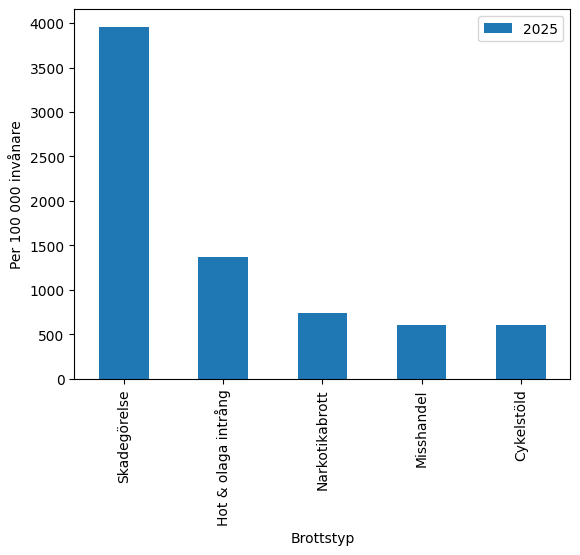

In [ ]:
# Vanligaste brotten per område 2025

# Bromma

df_plot = duckdb.sql("""
    SELECT Brottstyp, område, "2025"
    FROM df_cleaned
    WHERE område = 'Bromma'
    ORDER BY "2025" DESC    
    LIMIT 5       
""").df().plot(kind='bar', x='Brottstyp', y='2025', ylabel='Per 100 000 invånare')

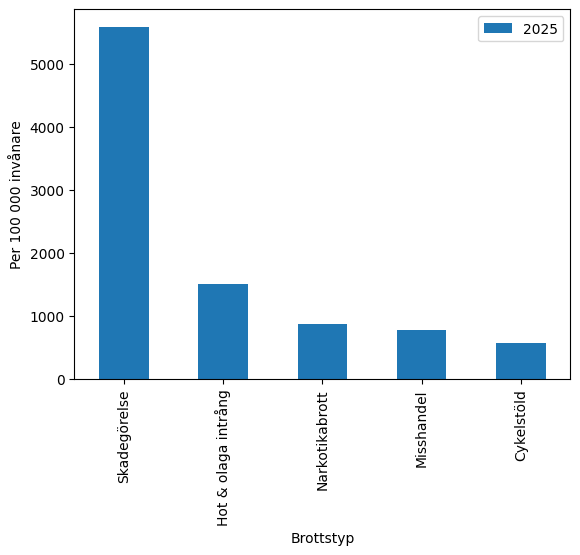

In [508]:
# Älvsjö

df_plot = duckdb.sql("""
    SELECT Brottstyp, område, "2025"
    FROM df_cleaned
    WHERE område = 'Älvsjö'
    ORDER BY "2025" DESC    
    LIMIT 5       
""").df().plot(kind='bar', x='Brottstyp', y='2025', ylabel='Per 100 000 invånare')

<Axes: xlabel='Brottstyp', ylabel='Per 100 000 invånare'>

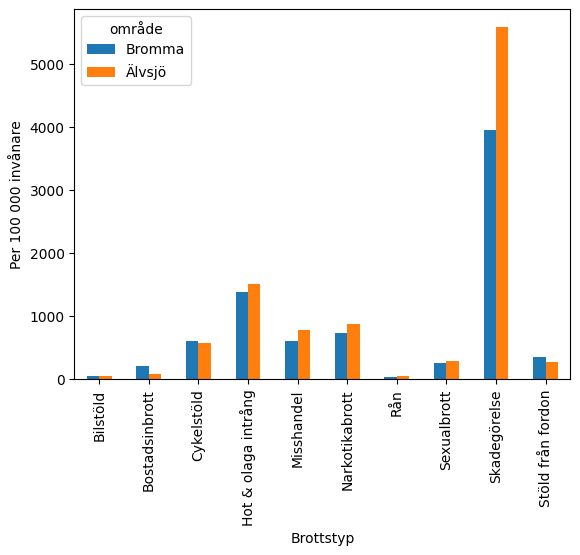

In [ ]:
# Jämförelse Älvsjö - Bromma (2025)

df_plot = duckdb.sql("""
    SELECT Brottstyp, område, "2025"
    FROM df_cleaned
    ORDER BY Brottstyp          
""").df()

df_plot.pivot(index='Brottstyp', columns='område', values='2025').plot(
    kind='bar',
    ylabel='Per 100 000 invånare'
)

## Eportera data set

In [512]:
df_cleaned.to_csv('../data_files/brottsstatistik_per_capita_cleaned.csv', index=False)